<h1>Step 1: Choose a Dataset</h1>
    <p style="text-indent: 40px;">Select a dataset from: UCI Machine Learning Repository</p>
The dataset must meet the following criteria:<br>
    <p style="text-indent: 40px;">Must be a classification problem (the target variable has discrete labels)</p>
    <p style="text-indent: 40px;">Have at least 500 samples</p>
    <p style="text-indent: 40px;">Have at least 4 features (excluding the label)</p>
    <p style="text-indent: 40px;">Picking a new database that we have not used already (e.g., the titanic dataset)</p>
<h1>Step 2: Preprocess the Data</h1>
    <p style="text-indent: 40px;">Perform basic data cleaning and preprocessing:</p>
    <p style="text-indent: 40px;">Handle missing values (drop or impute)</p>
    <p style="text-indent: 40px;">Convert categorical features to numeric (e.g., one-hot encoding)</p>
    <p style="text-indent: 40px;">Split the data into training and testing sets (e.g., 80/20 split)</p>
    <p style="text-indent: 40px;">Clearly explain any choices you make.</p>

<h1>Step 3: Train the Models</h1>
    <p style="text-indent: 40px;">Using scikit-learn or statsmodels:</p>
    <p style="text-indent: 40px;">Train the four models: Logistic regression, KNN, Decision Tree and SVM.</p>

<h1>Logistic Regression Model:</h1>

In [809]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, precision_recall_curve, roc_curve
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn import metrics
from sklearn import svm
import seaborn as sns
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

df = pd.read_csv('wdbc.data', header=None, na_values=["?", "NA", "-999"])

headers = ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
           'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
           'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
           'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
           'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
           'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst',
           'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 
           'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
df.columns = headers
df.insert(loc=2, column='malignant', value=df['diagnosis'].map({'M': 1, 'B': 0}))
df.insert(loc=3, column='benign', value=df['diagnosis'].map({'M': 0, 'B': 1}))
df.drop(columns=['diagnosis'], inplace=True)
for i in df.columns:
    if df[i].isnull().any():
        print(f"{i}: {df[i].dtype}")

print(df.head())

         id  malignant  benign  radius_mean  texture_mean  perimeter_mean  \
0    842302          1       0        17.99         10.38          122.80   
1    842517          1       0        20.57         17.77          132.90   
2  84300903          1       0        19.69         21.25          130.00   
3  84348301          1       0        11.42         20.38           77.58   
4  84358402          1       0        20.29         14.34          135.10   

   area_mean  smoothness_mean  compactness_mean  concavity_mean  ...  \
0     1001.0          0.11840           0.27760          0.3001  ...   
1     1326.0          0.08474           0.07864          0.0869  ...   
2     1203.0          0.10960           0.15990          0.1974  ...   
3      386.1          0.14250           0.28390          0.2414  ...   
4     1297.0          0.10030           0.13280          0.1980  ...   

   radius_worst  texture_worst  perimeter_worst  area_worst  smoothness_worst  \
0         25.38        

In [810]:
RANDOM_STATE = 42

feature_names = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']
print(f"Feature names: {feature_names}")
print("sample feature values:")
X = pd.DataFrame(df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']], columns=feature_names)
y = pd.Series(df['malignant'], name="target")

print(X.head())
print(y.head())

print(X.tail())
print(y.tail())

Feature names: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']
sample feature values:
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390

In [811]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

print('Train class rate:', y_train.mean().round(3))
print('Test class rate: ', y_test.mean().round(3))

Train class rate: 0.372
Test class rate:  0.374


In [812]:
baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

weighted_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

baseline_model.fit(X_train, y_train)
weighted_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['radius_mean','texture_mean','perimeter_mean',...,'concave points_mean', 'symmetry_mean','fractal_dimension_mean']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [813]:
def evaluate_model(name, model, X_eval, y_eval, threshold=0.50):
    prob = model.predict_proba(X_eval)[:, 1]
    pred = (prob >= threshold).astype(int)
    return {
        'model': name,
        'threshold': threshold,
        'accuracy': accuracy_score(y_eval, pred),
        'balanced_accuracy': balanced_accuracy_score(y_eval, pred),
        'precision': precision_score(y_eval, pred, zero_division=0),
        'recall': recall_score(y_eval, pred, zero_division=0),
        'f1': f1_score(y_eval, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_eval, prob),
        'average_precision': average_precision_score(y_eval, prob),
    }

results = pd.DataFrame([
    evaluate_model('baseline', baseline_model, X_test, y_test),
    evaluate_model('class_weight_balanced', weighted_model, X_test, y_test),
])
results.round(3)

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,baseline,0.5,0.942,0.938,0.922,0.922,0.922,0.988,0.982
1,class_weight_balanced,0.5,0.942,0.941,0.909,0.938,0.923,0.988,0.982


In [814]:
for name, model in [('baseline', baseline_model), ('class_weight_balanced', weighted_model)]:
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.50).astype(int)
    print(f'\n{name}')
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, digits=3, zero_division=0))


baseline
[[102   5]
 [  5  59]]
              precision    recall  f1-score   support

           0      0.953     0.953     0.953       107
           1      0.922     0.922     0.922        64

    accuracy                          0.942       171
   macro avg      0.938     0.938     0.938       171
weighted avg      0.942     0.942     0.942       171


class_weight_balanced
[[101   6]
 [  4  60]]
              precision    recall  f1-score   support

           0      0.962     0.944     0.953       107
           1      0.909     0.938     0.923        64

    accuracy                          0.942       171
   macro avg      0.935     0.941     0.938       171
weighted avg      0.942     0.942     0.942       171



In [815]:
from sklearn.model_selection import TunedThresholdClassifierCV
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE
)

threshold_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])
threshold_model.fit(X_train2, y_train2)

val_prob = threshold_model.predict_proba(X_val)[:, 1]
param_grid = {
    'model__threshold__':  [0.1, 0.3, 0.5, 0.7, 0.9]
}
tuned_model = TunedThresholdClassifierCV(estimator=threshold_model, scoring='recall', cv=5)
# grid_search = GridSearchCV(estimator=threshold_model, param_grid=param_grid, cv=5, scoring="recall", n_jobs=-1, threshold=)
tuned_model.fit(X_train2,y_train2)

candidate_thresholds = np.linspace(0.05, 0.95, 181)

threshold_rows = []

for t in candidate_thresholds:
    val_pred = (val_prob >= t).astype(int)
    threshold_rows.append({
        'threshold': t,
        'precision': precision_score(y_val, val_pred, zero_division=0),
        'recall': recall_score(y_val, val_pred, zero_division=0),
        'f1': f1_score(y_val, val_pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold = threshold_df.loc[threshold_df['recall'].idxmax(), 'threshold']
print('Best validation threshold by F1:', round(best_threshold, 3))
threshold_df.sort_values('f1', ascending=False).head(10).round(3)

print(f"tuned model best estimator for threshold {tuned_model.best_threshold_}")

Best validation threshold by F1: 0.05
tuned model best estimator for threshold 1.4869395647081908e-05


In [816]:
# Refit on the full training data, then apply the chosen threshold to the untouched test set.
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])
final_model.fit(X_train, y_train)

pd.DataFrame([
    evaluate_model('weighted_threshold_0.50', final_model, X_test, y_test, threshold=0.50),
    evaluate_model('weighted_tuned_threshold', final_model, X_test, y_test, threshold=best_threshold),
]).round(3)

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,weighted_threshold_0.50,0.50,0.942,0.941,0.909,0.938,0.923,0.988,0.982
1,weighted_tuned_threshold,0.05,0.836,0.869,0.696,1.000,0.821,0.988,0.982


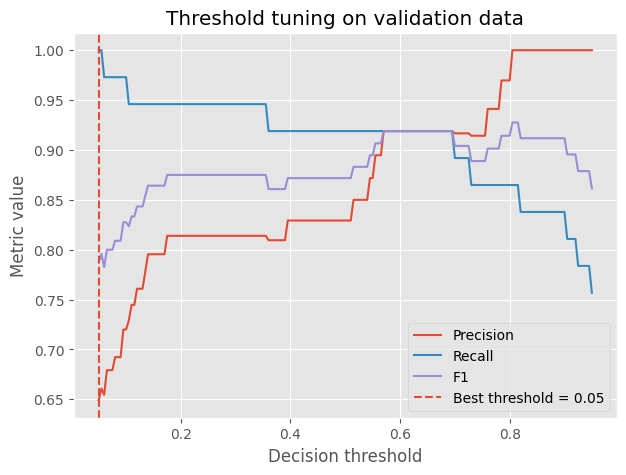

In [817]:
plt.figure(figsize=(7, 5))
plt.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1'], label='F1')
plt.axvline(best_threshold, linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Decision threshold')
plt.ylabel('Metric value')
plt.title('Threshold tuning on validation data')
plt.legend()
plt.show()

<h1>KNN Model:</h1>

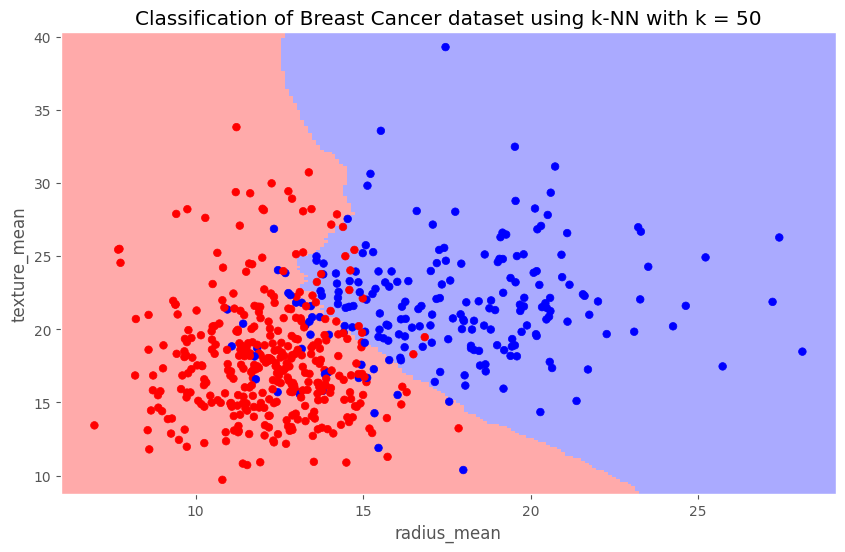

In [818]:
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('ggplot')

X = df[['radius_mean', 'texture_mean']].values
y = df['malignant'].values

# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1

# plot data
plt.scatter(X[:, 0], X[:, 1], c=y,  marker="o", cmap=cmap_bold, s=30)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)    

# set up the model, k-NN classification with k = ?  
k = 50
clf = KNeighborsClassifier(n_neighbors=k)
clf.fit(X, y)

# plot classification 
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),np.linspace(y_min, y_max, 200))
zz = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)>.1
plt.pcolormesh(xx, yy, zz, cmap=cmap_light)

# plot data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold,s=30)

plt.title('Classification of Breast Cancer dataset using k-NN with k = '+ str(k))
plt.xlabel('radius_mean')
plt.ylabel('texture_mean')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)    
plt.show()

In [819]:
y_pred = clf.predict(X)
print(f'Confusion Matrix: {metrics.confusion_matrix(y_true = y, y_pred = y_pred)[0]}, {metrics.confusion_matrix(y_true = y, y_pred = y_pred)[1]}')
print('Accuracy = ', metrics.accuracy_score(y_true = y, y_pred = y_pred))
print(f'Precision = {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[0][0]}, {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[0][1]}')
print(f'Recall = {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[1][0]}, {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[1][1]}')
print(f'F1 Score = {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[2][0]}, {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[2][1]}')
print(f'Support = {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[3][0]}, {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[3][1]}')

Confusion Matrix: [344  13], [ 39 173]
Accuracy =  0.9086115992970123
Precision = 0.8981723237597912, 0.9301075268817204
Recall = 0.9635854341736695, 0.8160377358490566
F1 Score = 0.9297297297297298, 0.8693467336683417
Support = 357, 212


<h1>Decision Tree Model:</h1>

In [820]:
labels =["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean", "compactness_mean", "concavity_mean", "concave points_mean", "symmetry_mean", "fractal_dimension_mean"]

def splitData(features):
    df_predictors = df[features].values
    df_labels = df["malignant"].values

    # Split into training and test sets
    XTrain, XTest, yTrain, yTest = train_test_split(df_predictors, df_labels, random_state=1, test_size=0.5)
    return XTrain, XTest, yTrain, yTest

XTrain shape: (284, 10), yTrain shape: (284,)
XTest shape: (285, 10), yTest shape: (285,)
Total samples in training set:  284
Total samples in test set:  285
Accuracy on training data =  1.0
Accuracy on test data =  0.887719298245614


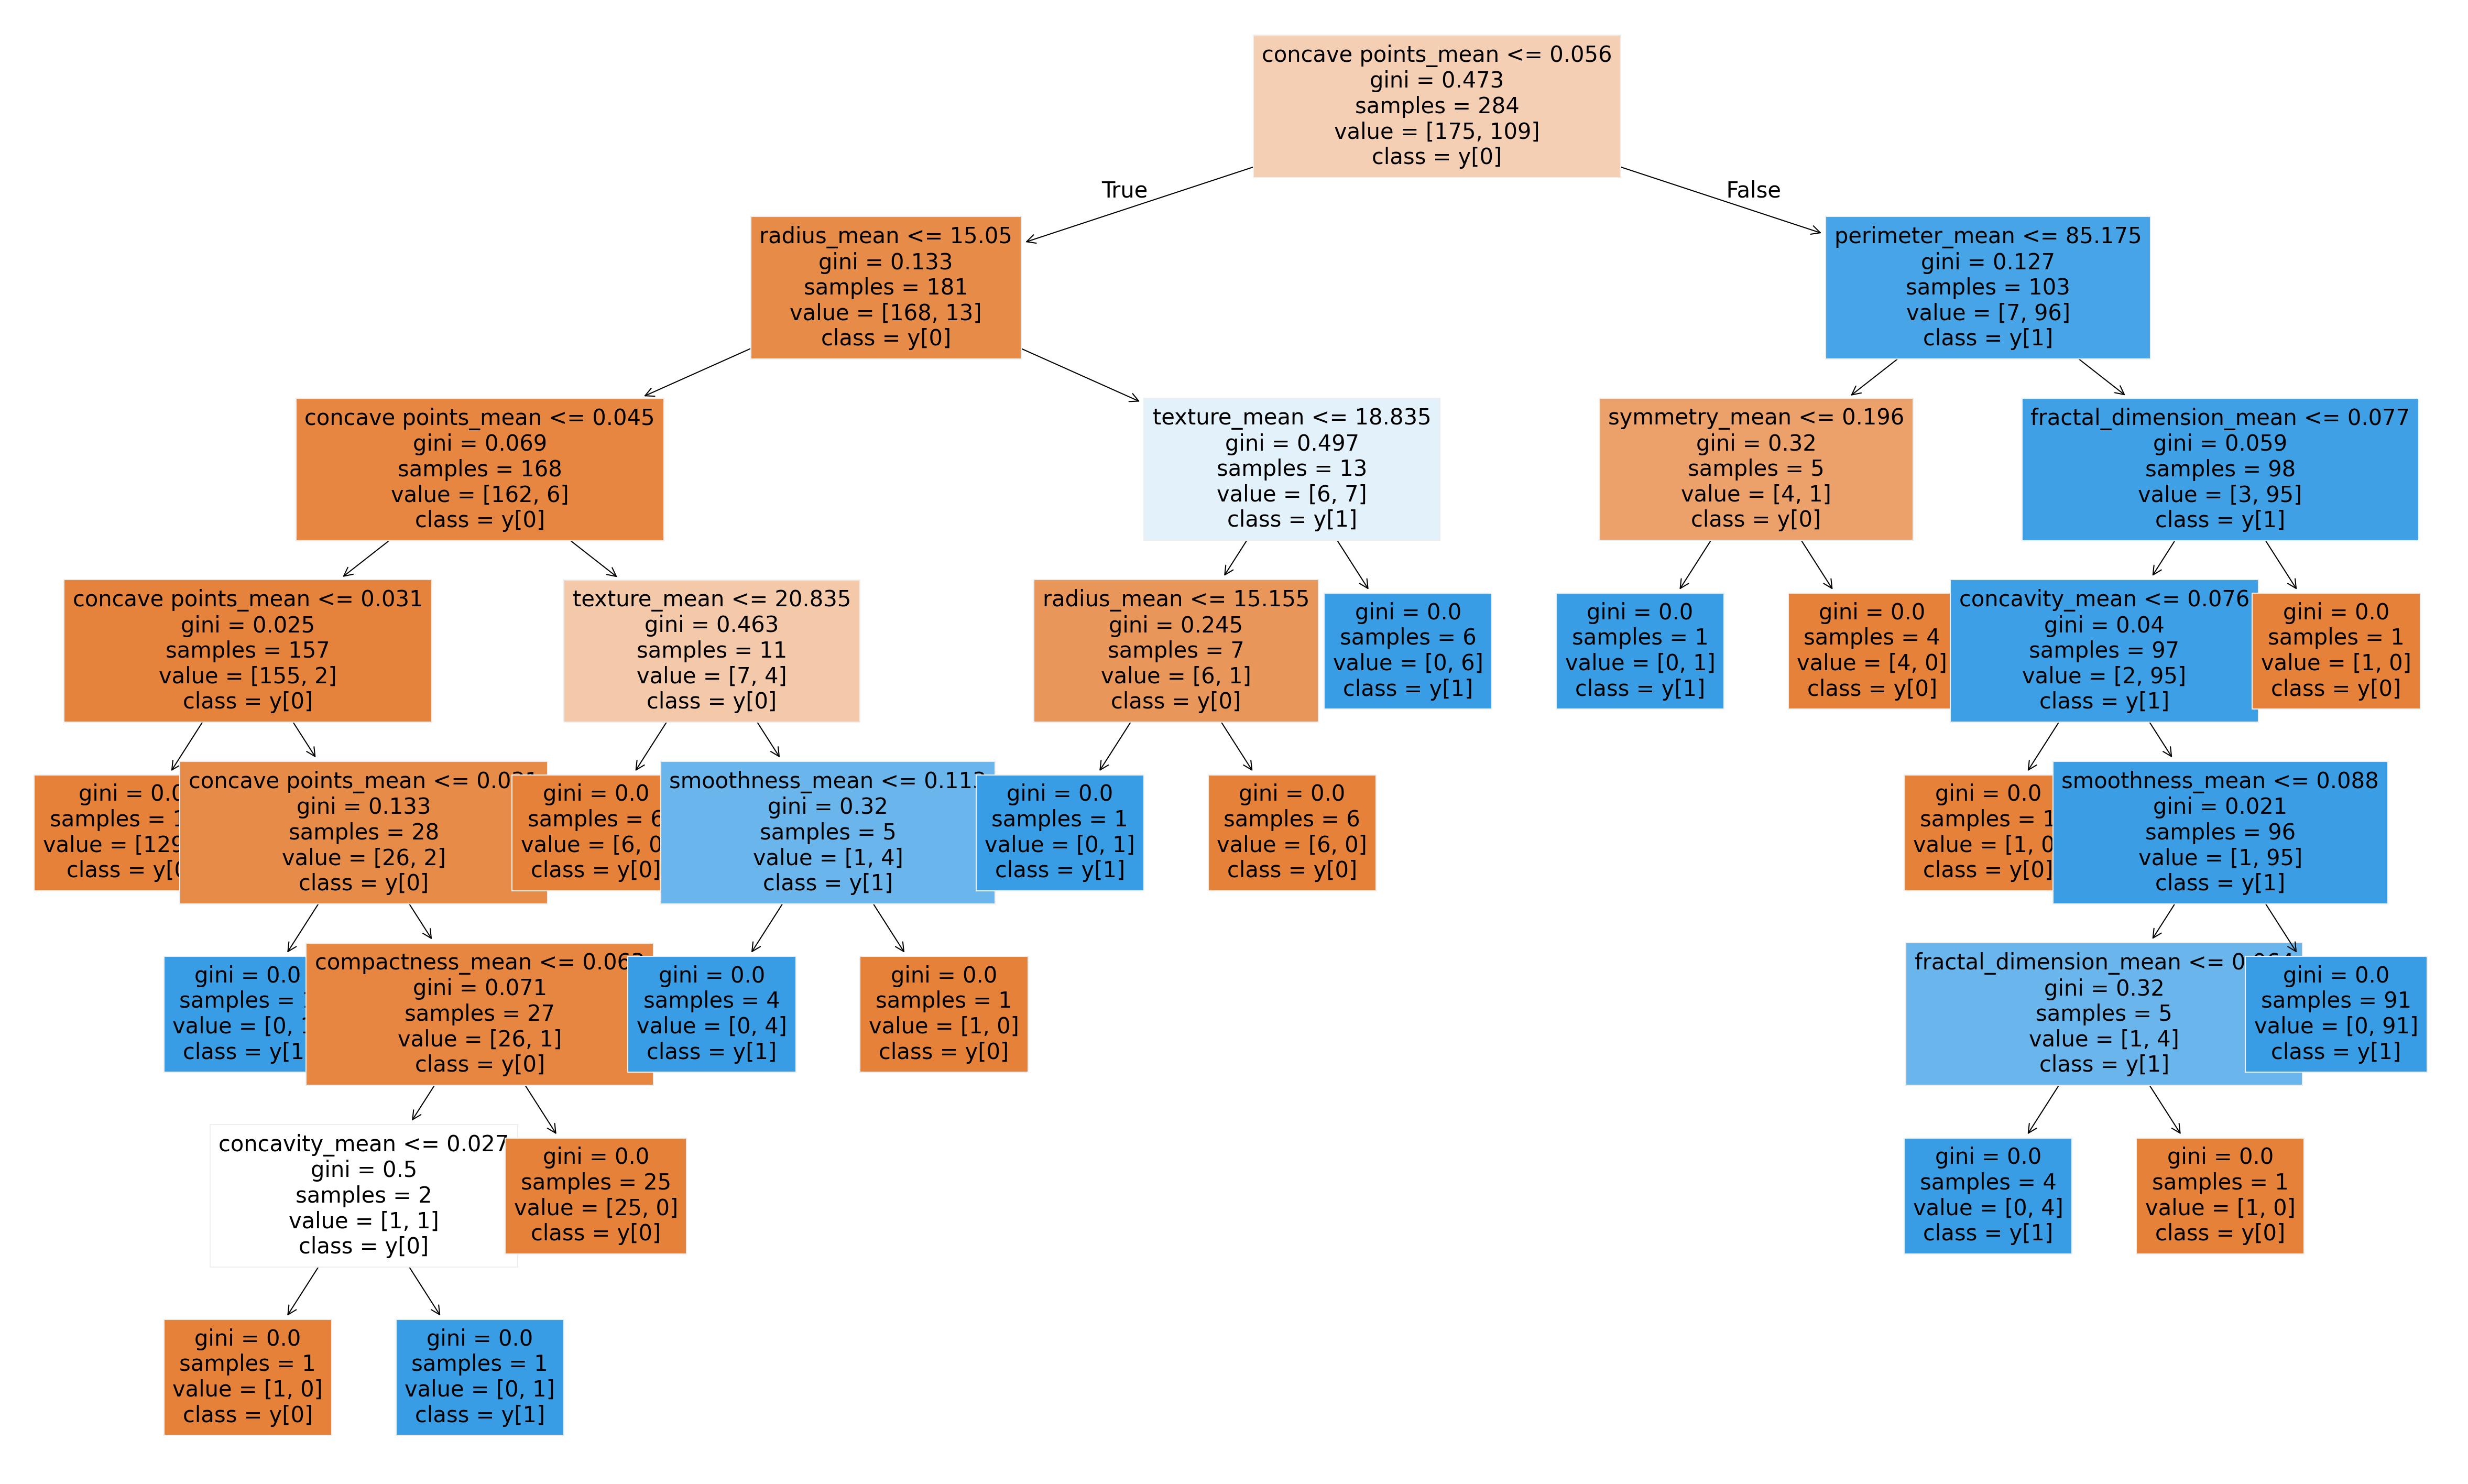

In [821]:
decisionTree = tree.DecisionTreeClassifier()

XTrain, XTest, yTrain, yTest = splitData(["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean", "compactness_mean", "concavity_mean", "concave points_mean", "symmetry_mean", "fractal_dimension_mean"])

print(f"XTrain shape: {XTrain.shape}, yTrain shape: {yTrain.shape}")

print(f"XTest shape: {XTest.shape}, yTest shape: {yTest.shape}")

print("Total samples in training set: ", len(XTrain))
print("Total samples in test set: ", len(XTest))
# fit the tree with the traing data
decisionTree = decisionTree.fit(XTrain, yTrain)

# predict with the training data
y_pred_train = decisionTree.predict(XTrain)
# measure accuracy
print('Accuracy on training data = ', metrics.accuracy_score(y_true = yTrain, y_pred = y_pred_train))

# predict with the test data
y_pred = decisionTree.predict(XTest)
# measure accuracy
print('Accuracy on test data = ', metrics.accuracy_score(y_true = yTest, y_pred = y_pred))


# 1. Define a large canvas size and high crispness (DPI = 300)
fig, ax = plt.subplots(figsize=(20, 12), dpi=300)

# 2. Plot the tree using your DataFrame's column names
plot_tree(
    decisionTree, 
    feature_names=["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean", "compactness_mean", "concavity_mean", "concave points_mean", "symmetry_mean", "fractal_dimension_mean"],  # Pulls labels from your pandas DataFrame
    class_names=True,                   # Adds target class labels if it's classification
    filled=True,                        # Colors nodes based on purity
    fontsize=10,                        # Keeps the text readable
    ax=ax
)

# 3. Save as a high-res image file
plt.savefig('decision_tree_visualization.png', bbox_inches='tight')
plt.show()

In [822]:
print('Confusion Matrix:')
y_pred = clf.predict(X)
print(metrics.confusion_matrix(y_true = y, y_pred = y_pred))

print('Accuracy = ', metrics.accuracy_score(y_true = y, y_pred = y_pred))
#print('ROC AUC Score = ',  metrics.roc_auc_score(y_true = y, y_pred = y_pred))
print(metrics.classification_report(y, clf.predict(X)))

Confusion Matrix:
[[344  13]
 [ 39 173]]
Accuracy =  0.9086115992970123
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       357
           1       0.93      0.82      0.87       212

    accuracy                           0.91       569
   macro avg       0.91      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569



<h1>SVM Model:</h1>

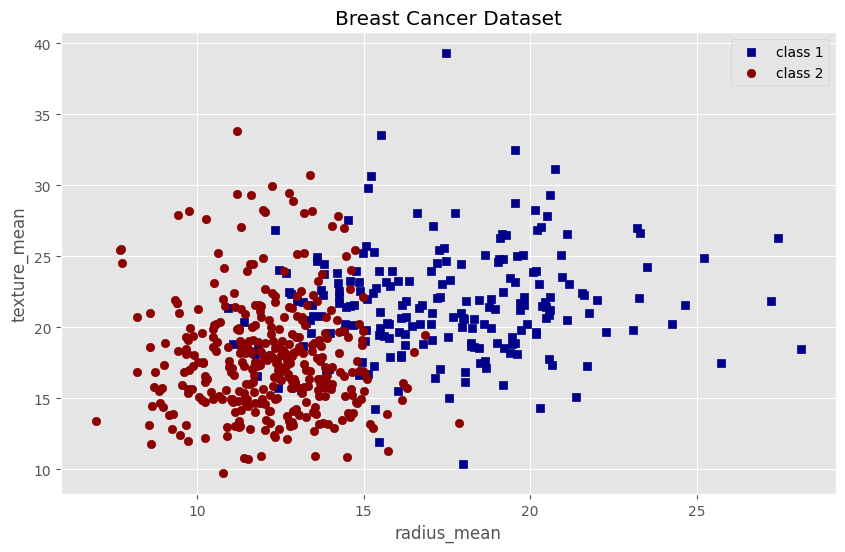

In [823]:
# there are two features contained in X and the labels are contained in y
# X,y = make_moons(n_samples=500,random_state=1,noise=0.3)
X = df[['radius_mean', 'texture_mean']].values
y = df['malignant'].values
# Plot the data, color by class
plt.scatter(X[y == 1, 0], X[y == 1, 1], color="DarkBlue", marker="s",label="class 1")
plt.scatter(X[y == 0, 0], X[y == 0, 1], color="DarkRed", marker="o",label="class 2")
plt.legend(scatterpoints=1)
plt.title('Breast Cancer Dataset')
plt.xlabel('radius_mean')
plt.ylabel('texture_mean')
plt.show()

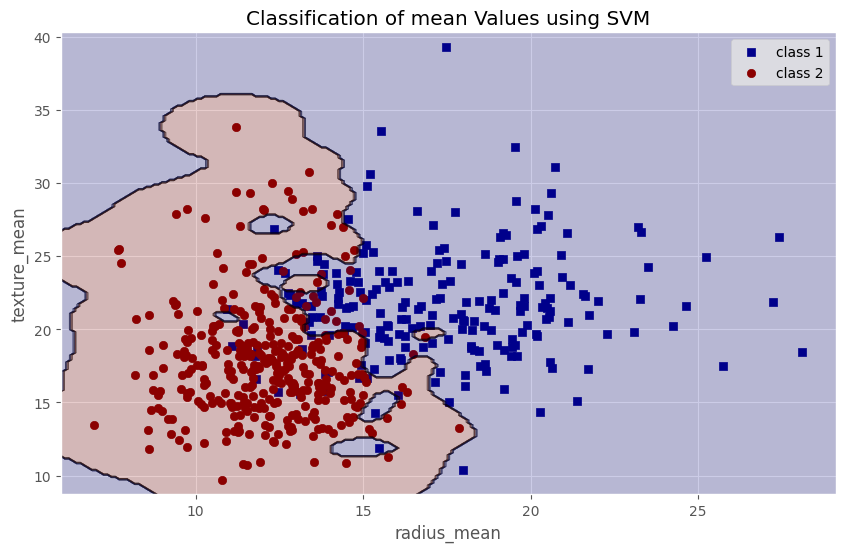

In [824]:
X = df[['radius_mean', 'texture_mean']].values
y = df['malignant'].values

model = svm.SVC(kernel='rbf', gamma='auto', C=75)
model.fit(X, y)

# Plot the data, color by class
plt.scatter(X[y == 1, 0], X[y == 1, 1], color="DarkBlue", marker="s",label="class 1")
plt.scatter(X[y == 0, 0], X[y == 0, 1], color="DarkRed", marker="o",label="class 2")
plt.legend(scatterpoints=1)

# Plot the predictions made by SVM
x_min, x_max = X[:,0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),np.linspace(y_min, y_max, 200))
zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, zz, cmap=ListedColormap(['DarkRed', 'DarkBlue']), alpha=.2)
plt.contour(xx, yy, zz, colors="black", alpha=1, linewidths=0.2) 

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title('Classification of mean Values using SVM')
plt.xlabel('radius_mean')
plt.ylabel('texture_mean')
plt.show()

In [825]:
y_pred = model.predict(X)
print(f'Confusion Matrix: {metrics.confusion_matrix(y_true = y, y_pred = y_pred)[0]}, {metrics.confusion_matrix(y_true = y, y_pred = y_pred)[1]}')
print('Accuracy = ', metrics.accuracy_score(y_true = y, y_pred = y_pred))
print(f'Precision = {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[0][0]}, {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[0][1]}')
print(f'Recall = {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[1][0]}, {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[1][1]}')
print(f'F1 Score = {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[2][0]}, {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[2][1]}')
print(f'Support = {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[3][0]}, {metrics.precision_recall_fscore_support(y_true = y, y_pred = y_pred)[3][1]}')

Confusion Matrix: [342  15], [ 20 192]
Accuracy =  0.9384885764499121
Precision = 0.9447513812154696, 0.927536231884058
Recall = 0.957983193277311, 0.9056603773584906
F1 Score = 0.9513212795549374, 0.9164677804295943
Support = 357, 212
